# Entrenamiento: ISIC 2019 — Dermatología

**Modelo:** EfficientNet-B4 | **Tarea:** Clasificación multiclase (8 clases) | **Semilla:** 698

## 1. Instalaciones

In [ ]:
!pip install -q --root-user-action=ignore torch torchvision timm monai nibabel faiss-cpu scikit-learn huggingface_hub openpyxl kagglehub opencv-python seaborn

## 2. Imports

In [ ]:
import os
import sys
import copy
import time
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

In [ ]:
import numpy as np
import pandas as pd
import kagglehub
import seaborn as sns
from PIL import Image

import matplotlib.pyplot as plt

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
import timm

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
import torchvision.transforms as T

from tqdm.notebook import tqdm

## 3. Configuración Global

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

torch.backends.cudnn.benchmark = True

print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")
if DEVICE.type == "cuda":
    props = torch.cuda.get_device_properties(0)
    print(f"GPU    : {props.name}")
    print(f"VRAM   : {props.total_memory / 1e9:.1f} GB")

## 3.1 Directorios de salida (DATA/)

In [8]:
DATA_DIR = Path("DATA")
DATA_ISIC_DIR = DATA_DIR / "isic"
DATA_PLOTS_DIR = DATA_DIR / "plots"

for _d in [DATA_ISIC_DIR, DATA_PLOTS_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

print("Directorios DATA/ creados:")
for _d in [DATA_ISIC_DIR, DATA_PLOTS_DIR]:
    print(f"  {_d}")

Directorios DATA/ creados:
  DATA/isic
  DATA/plots


## 4. Configuración ISIC 2019

In [9]:
ISIC_SEED = 698
ISIC_EPOCHS = 50
ISIC_BATCH_SIZE = 32
ISIC_LR = 3e-4
ISIC_N_CLASSES = 8
ISIC_ACCUM_STEPS = 4
ISIC_IMG_SIZE = 260

ISIC_BASE_DIR = DATA_ISIC_DIR
ISIC_CSV_PATH = ISIC_BASE_DIR / "ISIC_2019_Training_GroundTruth.csv"
ISIC_META_PATH = ISIC_BASE_DIR / "ISIC_2019_Training_Metadata.csv"
ISIC_CKPT_DIR = DATA_ISIC_DIR

ISIC_CLASS_NAMES = {
    "AK": "Actinic Keratosis",
    "BCC": "Basal Cell Carcinoma",
    "BKL": "Benign Keratosis",
    "DF": "Dermatofibroma",
    "MEL": "Melanoma",
    "NV": "Nevus",
    "SCC": "Squamous Cell Carcinoma",
    "VASC": "Vascular Lesion",
}
ISIC_CLASSES = sorted(ISIC_CLASS_NAMES.keys())
ISIC_CLASS2IDX = {c: i for i, c in enumerate(ISIC_CLASSES)}

## 5. Clases Utilitarias

In [10]:
class EarlyStopping:
    """Early stopping basado en F1-Macro con guardado de mejor modelo."""

    def __init__(self, patience=10, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_model_wts = None

    def __call__(self, val_f1, model, path="best.pth", ckpt_dict=None):
        if self.best_score is None:
            self.best_score = val_f1
            self.save_checkpoint(model, path, ckpt_dict=ckpt_dict)
        elif val_f1 < self.best_score + self.min_delta:
            self.counter += 1
            print(f"EarlyStopping: {self.counter} de {self.patience} epocas sin mejora.")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = val_f1
            self.save_checkpoint(model, path, ckpt_dict=ckpt_dict)
            self.counter = 0

    def save_checkpoint(self, model, path, ckpt_dict=None):
        self.best_model_wts = copy.deepcopy(model.state_dict())
        if ckpt_dict is not None:
            torch.save(ckpt_dict, path)
        else:
            torch.save({"model_state": model.state_dict()}, path)
        print(f"F1-Macro mejoro ({self.best_score:.4f}). Modelo guardado.")

## 6. Funciones Utilitarias

In [11]:
def find_img_dir(base):
    """Busca directorio con imagenes JPG dentro de base."""
    for root, dirs, files in os.walk(base):
        if len([f for f in files if f.lower().endswith(".jpg")]) > 100:
            return Path(root)
    return None

## 7. Dataset

In [12]:
class ISICDataset(Dataset):
    """Dataset ISIC2019 para clasificacion de lesiones cutaneas."""

    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("RGB")
        return self.transform(img), int(row["label_idx"])

## 8. Modelo

In [13]:
class ExpertoISIC(nn.Module):
    """Experto ISIC: EfficientNet-B4 para 8 clases de lesiones cutaneas."""

    def __init__(self, n_classes=8, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(
            "efficientnet_b4", pretrained=pretrained, num_classes=0
        )
        d = self.backbone.num_features
        self.head = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(d, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, n_classes)
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.head(features)

## 9. Entrenamiento: ISIC 2019

### 9.0 Descargar dataset ISIC 2019

In [14]:
import shutil

os.makedirs(str(ISIC_BASE_DIR), exist_ok=True)
if ISIC_CSV_PATH.exists():
    print("ISIC ya descargado, omitiendo descarga.")
else:
    _isic_kaggle_path = kagglehub.dataset_download("andrewmvd/isic-2019")
    print(f"Kaggle descargo en: {_isic_kaggle_path}")
    for item in Path(_isic_kaggle_path).iterdir():
        dest = ISIC_BASE_DIR / item.name
        if not dest.exists():
            shutil.move(str(item), str(dest))
    print(f"Descarga completada en: {ISIC_BASE_DIR}")

ISIC ya descargado, omitiendo descarga.


### 9.1 Preparar datos ISIC

In [15]:
print("\n" + "=" * 60)
print("  MODELO: ISIC2019 — EfficientNet-B4")
print("=" * 60)

torch.manual_seed(ISIC_SEED)
np.random.seed(ISIC_SEED)

print(f"Epocas : {ISIC_EPOCHS}  (prueba — cambiar a 30 en RunPod)")
print(
    f"Batch  : {ISIC_BATCH_SIZE} x {ISIC_ACCUM_STEPS} acum = "
    f"{ISIC_BATCH_SIZE * ISIC_ACCUM_STEPS} efectivo"
)

ISIC_IMG_DIR = find_img_dir(str(ISIC_BASE_DIR))

gt = pd.read_csv(ISIC_CSV_PATH)
label_cols = [c for c in gt.columns if c != "image"]
gt["label"] = gt[label_cols].idxmax(axis=1)
gt = gt[gt["label"].isin(ISIC_CLASSES)].copy()
gt["filepath"] = gt["image"].apply(lambda x: str(ISIC_IMG_DIR / f"{x}.jpg"))
gt["label_idx"] = gt["label"].map(ISIC_CLASS2IDX)
gt["file_exists"] = gt["filepath"].apply(os.path.exists)
gt = gt[gt["file_exists"]].reset_index(drop=True)

train_df, val_df = train_test_split(
    gt, test_size=0.2, random_state=ISIC_SEED, stratify=gt["label"]
)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f"Total imagenes : {len(gt):,}")
print(f"Train          : {len(train_df):,}")
print(f"Val            : {len(val_df):,}")
print(f"Clases         : {ISIC_CLASSES}")


  MODELO: ISIC2019 — EfficientNet-B4
Epocas : 50  (prueba — cambiar a 30 en RunPod)
Batch  : 32 x 4 acum = 128 efectivo
Total imagenes : 25,331
Train          : 20,264
Val            : 5,067
Clases         : ['AK', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'SCC', 'VASC']


### 9.2 Class weights y transforms ISIC

In [16]:
weights = compute_class_weight(
    "balanced", classes=np.arange(ISIC_N_CLASSES), y=train_df["label_idx"].values
)
weights_tensor = torch.tensor(weights, dtype=torch.float).to(DEVICE)

print("Class weights:")
for cls, w in zip(ISIC_CLASSES, weights):
    print(f"  {ISIC_CLASS_NAMES[cls]:30s}: {w:.4f}")

isic_train_tfm = T.Compose(
    [
        T.Resize((ISIC_IMG_SIZE + 32, ISIC_IMG_SIZE + 32)),
        T.RandomCrop(ISIC_IMG_SIZE),
        T.RandomHorizontalFlip(),
        T.RandomVerticalFlip(),
        T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.1),
        T.RandomRotation(45),
        T.RandomGrayscale(p=0.05),
        T.ToTensor(),
        T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]
)

isic_val_tfm = T.Compose(
    [
        T.Resize((ISIC_IMG_SIZE, ISIC_IMG_SIZE)),
        T.ToTensor(),
        T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]
)

Class weights:
  Actinic Keratosis             : 3.6499
  Basal Cell Carcinoma          : 0.9530
  Benign Keratosis              : 1.2068
  Dermatofibroma                : 13.2618
  Melanoma                      : 0.7001
  Nevus                         : 0.2459
  Squamous Cell Carcinoma       : 5.0458
  Vascular Lesion               : 12.5396


### 9.3 DataLoaders ISIC

In [17]:
train_loader = DataLoader(
    ISICDataset(train_df, isic_train_tfm),
    batch_size=ISIC_BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)
val_loader = DataLoader(
    ISICDataset(val_df, isic_val_tfm),
    batch_size=ISIC_BATCH_SIZE * 2,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")

Train batches : 634
Val batches   : 80


### 9.4 Modelo, optimizador y scheduler ISIC

In [18]:
model = ExpertoISIC(n_classes=ISIC_N_CLASSES).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=weights_tensor, label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=ISIC_LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-6
)
scaler = GradScaler(enabled=(DEVICE.type == "cuda"))
early_stopping_isic = EarlyStopping(patience=10, min_delta=0.001)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Modelo         : EfficientNet-B4")
print(f"Parametros     : {total_params:,}")
print(f"Entrenables    : {trainable_params:,}")
print(f"Features dim   : {model.backbone.num_features}")

ISIC_CKPT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Checkpoints se guardan en: {ISIC_CKPT_DIR}")

Modelo         : EfficientNet-B4
Parametros     : 18,470,736
Entrenables    : 18,470,736
Features dim   : 1792
Checkpoints se guardan en: DATA/isic


### 9.5 Training loop ISIC

In [19]:
history = {"train_loss": [], "val_loss": [], "val_f1": []}
best_f1 = 0.0

for epoch in range(1, ISIC_EPOCHS + 1):
    model.train()
    total_loss = 0
    optimizer.zero_grad()

    pbar = tqdm(train_loader, desc=f"Epoca {epoch}/{ISIC_EPOCHS} [train]", leave=False)
    for step, (imgs, labels) in enumerate(pbar):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        with autocast(device_type=DEVICE.type, enabled=(DEVICE.type == "cuda")):
            logits = model(imgs)
            loss = criterion(logits, labels) / ISIC_ACCUM_STEPS

        scaler.scale(loss).backward()

        if (step + 1) % ISIC_ACCUM_STEPS == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        total_loss += loss.item() * ISIC_ACCUM_STEPS
        pbar.set_postfix({"loss": f"{total_loss / (step + 1):.4f}"})

    if (step + 1) % ISIC_ACCUM_STEPS != 0:
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()

    train_loss = total_loss / len(train_loader)

    model.eval()
    val_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in tqdm(
            val_loader, desc=f"Epoca {epoch}/{ISIC_EPOCHS} [val]", leave=False
        ):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            with autocast(device_type=DEVICE.type, enabled=(DEVICE.type == "cuda")):
                logits = model(imgs)
                loss = criterion(logits, labels)
            val_loss += loss.item()
            all_preds.extend(logits.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss /= len(val_loader)
    val_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_f1"].append(val_f1)

    scheduler.step()

    print(
        f"Epoca {epoch:2d}/{ISIC_EPOCHS} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"F1_macro={val_f1:.4f}",
        end="",
    )

    ckpt = {
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optim_state": optimizer.state_dict(),
        "val_f1": val_f1,
        "val_loss": val_loss,
        "history": history,
        "classes": ISIC_CLASSES,
        "class2idx": ISIC_CLASS2IDX,
    }

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(ckpt, ISIC_CKPT_DIR / "experto_isic_best.pt")
        print(f"  <- mejor F1, guardado en {ISIC_CKPT_DIR}/experto_isic_best.pt")
    else:
        print()

    early_stopping_isic(
        val_f1, model, path=str(ISIC_CKPT_DIR / "experto_isic_best.pth"), ckpt_dict=ckpt
    )
    if early_stopping_isic.early_stop:
        print(f"  Early stopping en epoca {epoch}")
        break

print(f"\nMejor F1 Macro: {best_f1:.4f}")

Epoca 1/50 [train]:   0%|          | 0/634 [00:00<?, ?it/s]

Epoca 1/50 [val]:   0%|          | 0/80 [00:00<?, ?it/s]

Epoca  1/50 | train_loss=2.6362 | val_loss=2.2744 | F1_macro=0.3488  <- mejor F1, guardado en DATA/isic/experto_isic_best.pt
F1-Macro mejoro (0.3488). Modelo guardado.


Epoca 2/50 [train]:   0%|          | 0/634 [00:00<?, ?it/s]

Epoca 2/50 [val]:   0%|          | 0/80 [00:00<?, ?it/s]

...

Epoca 49/50 [val]:   0%|          | 0/80 [00:00<?, ?it/s]

Epoca 49/50 | train_loss=1.5549 | val_loss=1.8392 | F1_macro=0.7352
EarlyStopping: 3 de 10 epocas sin mejora.


Epoca 50/50 [train]:   0%|          | 0/634 [00:00<?, ?it/s]

Epoca 50/50 [val]:   0%|          | 0/80 [00:00<?, ?it/s]

Epoca 50/50 | train_loss=1.5636 | val_loss=1.8446 | F1_macro=0.7301
EarlyStopping: 4 de 10 epocas sin mejora.

Mejor F1 Macro: 0.7421


### 9.6 Curvas de entrenamiento ISIC

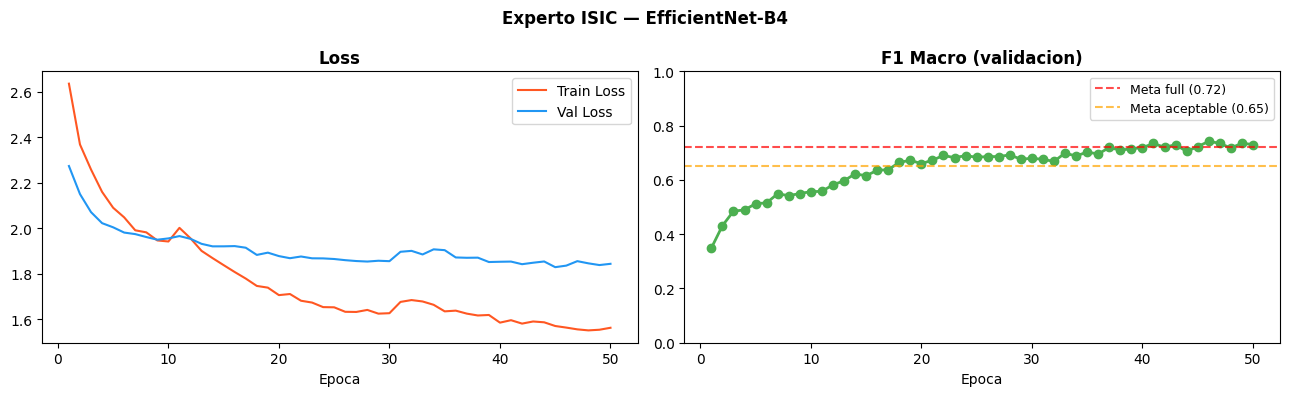

Guardado: DATA/plots/experto_isic_curvas.png


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
epochs_range = range(1, len(history["val_f1"]) + 1)

axes[0].plot(epochs_range, history["train_loss"], label="Train Loss", color="#FF5722")
axes[0].plot(epochs_range, history["val_loss"], label="Val Loss", color="#2196F3")
axes[0].set_title("Loss", fontweight="bold")
axes[0].set_xlabel("Epoca")
axes[0].legend()

axes[1].plot(epochs_range, history["val_f1"], color="#4CAF50", lw=2, marker="o")
axes[1].axhline(0.72, color="red", ls="--", alpha=0.7, label="Meta full (0.72)")
axes[1].axhline(0.65, color="orange", ls="--", alpha=0.7, label="Meta aceptable (0.65)")
axes[1].set_title("F1 Macro (validacion)", fontweight="bold")
axes[1].set_xlabel("Epoca")
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=9)

plt.suptitle("Experto ISIC — EfficientNet-B4", fontweight="bold")
plt.tight_layout()
plt.savefig(str(DATA_PLOTS_DIR / "experto_isic_curvas.png"), bbox_inches="tight", dpi=130)
plt.show()
print(f"Guardado: {DATA_PLOTS_DIR}/experto_isic_curvas.png")

### 9.7 Evaluación final ISIC

In [21]:
ckpt = torch.load(ISIC_CKPT_DIR / "experto_isic_best.pt", map_location=DEVICE)
model.load_state_dict(
    ckpt["model_state"] if isinstance(ckpt, dict) and "model_state" in ckpt else ckpt
)
model.eval()

all_preds, all_labels, isic_probs = [], [], []
with torch.no_grad():
    for imgs, labels in tqdm(val_loader, desc="Evaluacion final"):
        with autocast(device_type=DEVICE.type, enabled=(DEVICE.type == "cuda")):
            logits = model(imgs.to(DEVICE))
        probs = F.softmax(logits, dim=1).cpu().numpy()
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.numpy())
        isic_probs.extend(probs)
isic_probs = np.array(isic_probs)

f1_macro = f1_score(all_labels, all_preds, average="macro", zero_division=0)

print("=" * 60)
print("EXPERTO ISIC — REPORTE FINAL")
print("=" * 60)
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=[ISIC_CLASS_NAMES[c] for c in ISIC_CLASSES],
        zero_division=0,
    )
)
print(f"F1 Macro        : {f1_macro:.4f}")
print(f"Mejor epoca     : {ckpt.get('epoch', 'N/A')}")
print(f"Epocas corridas : {ISIC_EPOCHS}  (de 30 totales en RunPod)")

if f1_macro >= 0.72:
    print("Estado          : CUMPLE meta full (> 0.72)")
elif f1_macro >= 0.65:
    print("Estado          : CUMPLE meta aceptable (> 0.65)")
else:
    print(
        f"Estado          : por debajo — normal con {ISIC_EPOCHS} epocas, subira con 30"
    )

print()
print(f"Checkpoint guardado en: {ISIC_CKPT_DIR}/experto_isic_best.pt")

Evaluacion final:   0%|          | 0/80 [00:00<?, ?it/s]

EXPERTO ISIC — REPORTE FINAL
                         precision    recall  f1-score   support

      Actinic Keratosis       0.73      0.80      0.76       173
   Basal Cell Carcinoma       0.85      0.91      0.88       665
       Benign Keratosis       0.73      0.78      0.75       525
         Dermatofibroma       0.26      0.77      0.39        48
               Melanoma       0.83      0.74      0.79       904
                  Nevus       0.92      0.88      0.90      2575
Squamous Cell Carcinoma       0.71      0.77      0.74       126
        Vascular Lesion       0.64      0.84      0.73        51

               accuracy                           0.84      5067
              macro avg       0.71      0.81      0.74      5067
           weighted avg       0.85      0.84      0.84      5067

F1 Macro        : 0.7421
Mejor epoca     : 46
Epocas corridas : 50  (de 30 totales en RunPod)
Estado          : CUMPLE meta full (> 0.72)

Checkpoint guardado en: DATA/isic/experto_isic_be

### 9.8 Gráficos ISIC — Loss, F1, ROC, Confusion Matrix

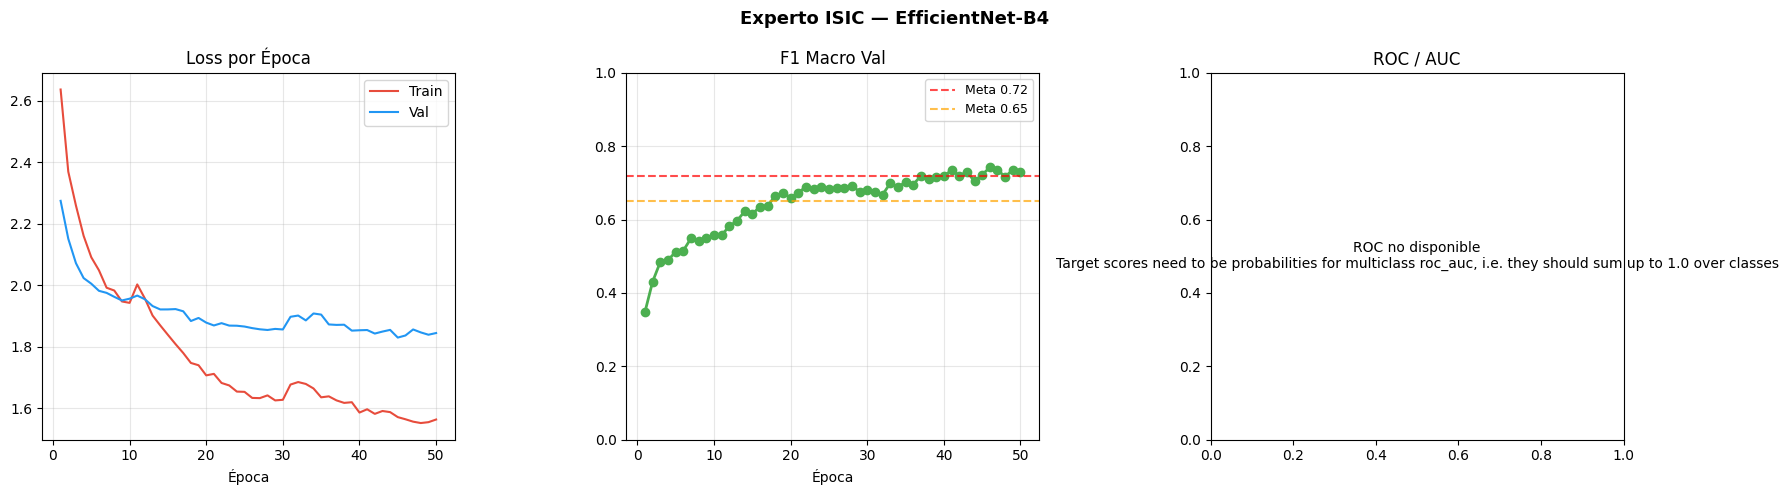

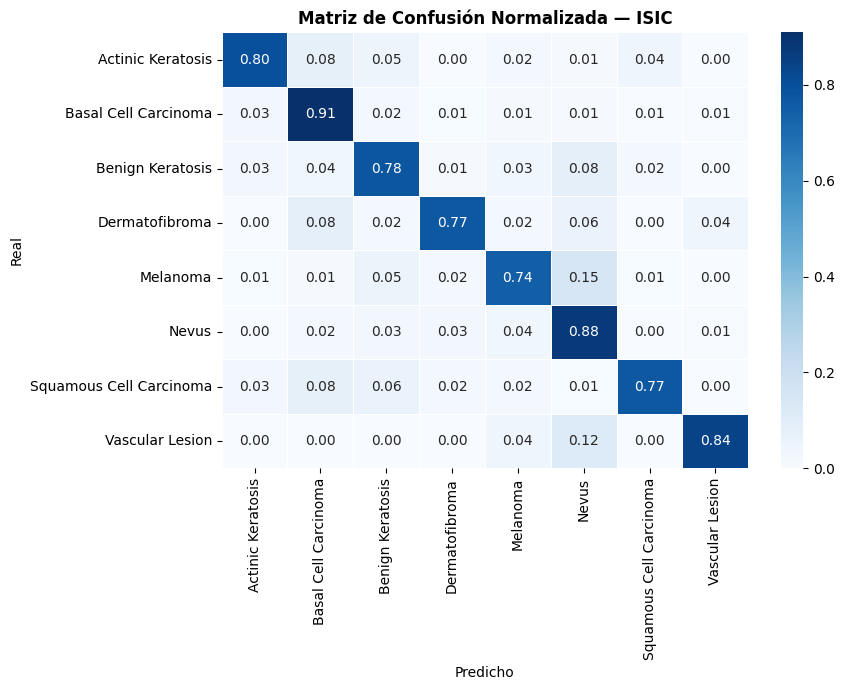

Gráficos guardados en DATA/plots


In [22]:
_isic_labels_arr = np.array(all_labels)
_isic_preds_arr = np.array(all_preds)
_isic_class_names = [ISIC_CLASS_NAMES[c] for c in ISIC_CLASSES]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Experto ISIC — EfficientNet-B4", fontsize=13, fontweight="bold")

_epochs_r = range(1, len(history["train_loss"]) + 1)
axes[0].plot(_epochs_r, history["train_loss"], label="Train", color="#e74c3c")
axes[0].plot(_epochs_r, history["val_loss"], label="Val", color="#2196F3")
axes[0].set_title("Loss por Época")
axes[0].set_xlabel("Época")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(_epochs_r, history["val_f1"], color="#4CAF50", lw=2, marker="o")
axes[1].axhline(0.72, color="red", ls="--", alpha=0.7, label="Meta 0.72")
axes[1].axhline(0.65, color="orange", ls="--", alpha=0.7, label="Meta 0.65")
axes[1].set_title("F1 Macro Val")
axes[1].set_xlabel("Época")
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

try:
    _auc_isic = roc_auc_score(
        _isic_labels_arr, isic_probs, multi_class="ovr", average="macro"
    )
    axes[2].bar(_isic_class_names, isic_probs.mean(axis=0), color="#9b59b6")
    axes[2].set_title(f"Score medio por clase\n(AUC OvR macro = {_auc_isic:.4f})")
    axes[2].set_xlabel("Clase")
    axes[2].set_ylabel("Prob. media")
    axes[2].tick_params(axis="x", rotation=45)
except Exception as _e:
    axes[2].text(
        0.5, 0.5, f"ROC no disponible\n{_e}", ha="center", va="center",
        transform=axes[2].transAxes,
    )
    axes[2].set_title("ROC / AUC")

plt.tight_layout()
plt.savefig(str(DATA_PLOTS_DIR / "experto_isic_curvas.png"), bbox_inches="tight", dpi=130)
plt.show()

fig2, ax2 = plt.subplots(figsize=(9, 7))
_cm_isic = confusion_matrix(_isic_labels_arr, _isic_preds_arr, normalize="true")
sns.heatmap(
    _cm_isic, annot=True, fmt=".2f", cmap="Blues",
    xticklabels=_isic_class_names, yticklabels=_isic_class_names,
    linewidths=0.5, ax=ax2,
)
ax2.set_title("Matriz de Confusión Normalizada — ISIC", fontweight="bold")
ax2.set_ylabel("Real")
ax2.set_xlabel("Predicho")
plt.tight_layout()
plt.savefig(str(DATA_PLOTS_DIR / "experto_isic_confusion.png"), bbox_inches="tight", dpi=130)
plt.show()
print(f"Gráficos guardados en {DATA_PLOTS_DIR}")